In [9]:
import glob
from tasks import cmj
vel_files = sorted(glob.glob("data/keypoints/bsq/*.txt"))   # or ohp/, adjust path
print(len(vel_files), "files")
print(vel_files[:3])
df = cmj.load_pose_file(vel_files[0])
print(df.shape, "columns:", list(df.columns)[:6], "...")

32 files
['data/keypoints/bsq\\P03_BSQ_FRONT.txt', 'data/keypoints/bsq\\P03_BSQ_FRONT_world.txt', 'data/keypoints/bsq\\P04_BACK_SQUAT_FRONT.txt']
(631, 99) columns: ['NOSE_x', 'NOSE_y', 'NOSE_z', 'LEFT_EYE_INNER_x', 'LEFT_EYE_INNER_y', 'LEFT_EYE_INNER_z'] ...


In [10]:
from utilities import utils
ohp = utils.read_list('ohp_data')
print(type(ohp), len(ohp))
print(ohp[0].keys())                    # is it 'left'/'right' or 'bl'/'ul'?
print(ohp[0]['left'].keys() if 'left' in ohp[0] else "no 'left' key")

<class 'list'> 16
dict_keys(['right', 'left'])
dict_keys(['coda', 'op'])


In [11]:
import numpy as np
from utilities import utils
from tasks import cmj

ohp = utils.read_list('ohp_data')        # or bsq_data
p = ohp[0]
pickle_sig = p['left']['op']
print("pickle op shape:", np.array(pickle_sig).shape)
print("pickle op[:,1] first vals:", np.array(pickle_sig)[:5, 1])

# load the matching txt and compare candidate landmarks
import glob
f = next(p for p in sorted(glob.glob("data/keypoints/ohp/*.txt"))
         if "P03" in p and "world" not in p.lower())
df = cmj.load_pose_file(f)
for cand in ["LEFT_WRIST_y", "LEFT_ELBOW_y", "LEFT_SHOULDER_y", "LEFT_INDEX_y"]:
    print(cand, df[cand].to_numpy()[:5])

pickle op shape: (638, 3)
pickle op[:,1] first vals: [59.318 59.304 59.221 55.978 55.978]
LEFT_WRIST_y [0.48246926 0.48235759 0.48219934 0.48219624 0.48226041]
LEFT_ELBOW_y [0.52578795 0.52581275 0.52582729 0.52600688 0.52643234]
LEFT_SHOULDER_y [0.48093492 0.48113841 0.48139104 0.48143736 0.48154718]
LEFT_INDEX_y [0.47058994 0.47001156 0.46986836 0.46984506 0.46987706]


In [12]:
import numpy as np
from utilities import utils
from tasks import cmj
import glob

ohp = utils.read_list('ohp_data')
pickle_sig = np.array(ohp[0]['left']['op'])[:, 1]   # the op y-signal

f = next(p for p in sorted(glob.glob("data/keypoints/ohp/*.txt"))
         if "P03" in p and "world" not in p.lower())
df = cmj.load_pose_file(f)

# correlate against every _y landmark, allowing for length mismatch
n = min(len(pickle_sig), len(df))
ps = pickle_sig[:n]
best = []
for col in [c for c in df.columns if c.endswith("_y")]:
    sig = df[col].to_numpy()[:n]
    # correlation is sign/scale invariant, catches flips too
    r = np.corrcoef(ps, sig)[0, 1]
    best.append((abs(r), r, col))
best.sort(reverse=True)
print("top matches (|r|, r, landmark):")
for b in best[:6]:
    print(f"  {b[0]:.3f}  {b[1]:+.3f}  {b[2]}")
print("\npickle len:", len(pickle_sig), " txt len:", len(df))

top matches (|r|, r, landmark):
  0.997  -0.997  LEFT_PINKY_y
  0.997  -0.997  RIGHT_WRIST_y
  0.997  -0.997  RIGHT_PINKY_y
  0.997  -0.997  LEFT_WRIST_y
  0.997  -0.997  RIGHT_ELBOW_y
  0.997  -0.997  RIGHT_THUMB_y

pickle len: 638  txt len: 637


16 bsq files / 16 ohp files


ValueError: Axis limits cannot be NaN or Inf

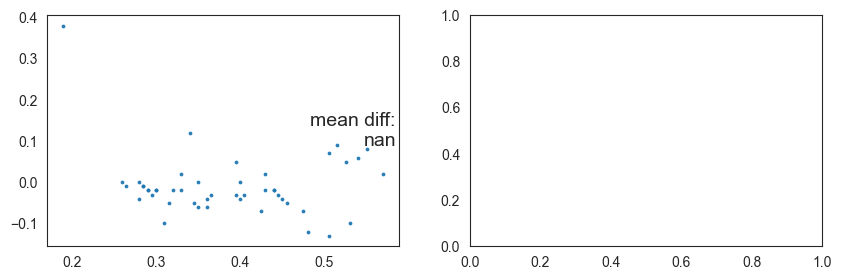

In [13]:
import glob
from utilities import utils
from tasks import velocity

bsq = sorted(p for p in glob.glob("data/keypoints/bsq/*.txt")
             if "world" not in p.lower())
ohp = sorted(p for p in glob.glob("data/keypoints/ohp/*.txt")
             if "world" not in p.lower())
bsq_data = utils.read_list('bsq_data')
ohp_data = utils.read_list('ohp_data')
print(len(bsq), "bsq files /", len(ohp), "ohp files")

bsq_h = velocity.get_metrics(bsq, bsq_data, task='bsq', task_label='Back Squat', ptm='height')
bsq_h

In [ ]:
# overhead press, height
ohp_h = velocity.get_metrics(ohp, ohp_data, task='ohp', task_label='Overhead Press', ptm='height')
ohp_h

KeyError: 'coda_ohp_1_pv'

In [ ]:
import numpy as np
from scipy.signal import savgol_filter
from utilities import utils
from tasks import velocity, cmj

# OMC side for P03 OHP
p = ohp_data[0]
omc = savgol_filter(p['left']['coda'][:,2], 21, 2)
cseg, creps = utils.get_reps(omc, fps=100, plot=False, d=1, forward=1.5, rewind=1.5)
print("OMC reps found:", len(creps))

# MMC side for P03 OHP
fp = next(p for p in ohp if "P03" in p)
mmc = savgol_filter(velocity._bar_signal(fp), 21, 2)
oseg, oreps = utils.get_reps(mmc, fps=30, plot=False, d=1, forward=1.5, rewind=1.5)
print("MMC reps found:", len(oreps))

OMC reps found: 3
MMC reps found: 1


In [ ]:
# try flipping the MMC signal
mmc_flip = savgol_filter(-velocity._bar_signal(fp), 21, 2)
oseg, oreps = utils.get_reps(mmc_flip, fps=30, plot=False, d=1, forward=1.5, rewind=1.5)
print("MMC reps (flipped):", len(oreps))

MMC reps (flipped): 3


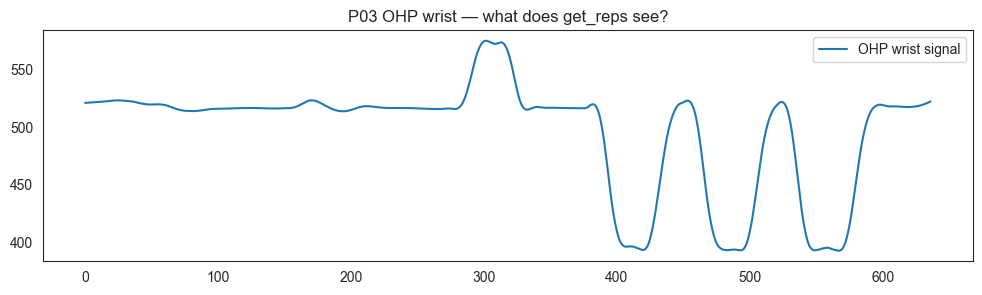

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,3))
plt.plot(mmc, label="OHP wrist signal")
plt.title("P03 OHP wrist — what does get_reps see?")
plt.legend(); plt.show()

ValueError: Axis limits cannot be NaN or Inf

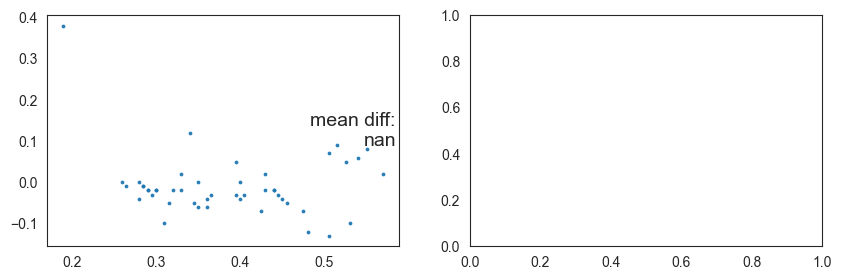

In [ ]:
# 1. confirm back squat STILL matches (must stay ~0.05 / 0.04)
bsq_h = velocity.get_metrics(bsq, bsq_data, task='bsq', task_label='Back Squat', ptm='height')
print("BSQ height:"); print(bsq_h)

# 2. now OHP, which should work with the per-task flip
ohp_h = velocity.get_metrics(ohp, ohp_data, task='ohp', task_label='Overhead Press', ptm='height')
print("OHP height:"); print(ohp_h)

ValueError: Axis limits cannot be NaN or Inf

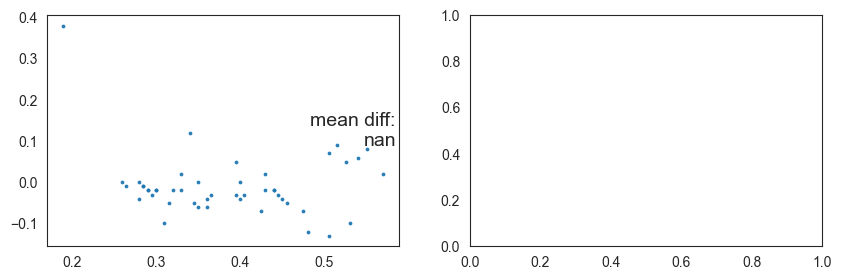

In [14]:
bsq_h = velocity.get_metrics(bsq, bsq_data, task='bsq', task_label='Back Squat', ptm='height')
print("BSQ height:"); print(bsq_h)

ohp_h = velocity.get_metrics(ohp, ohp_data, task='ohp', task_label='Overhead Press', ptm='height')
print("OHP height:"); print(ohp_h)

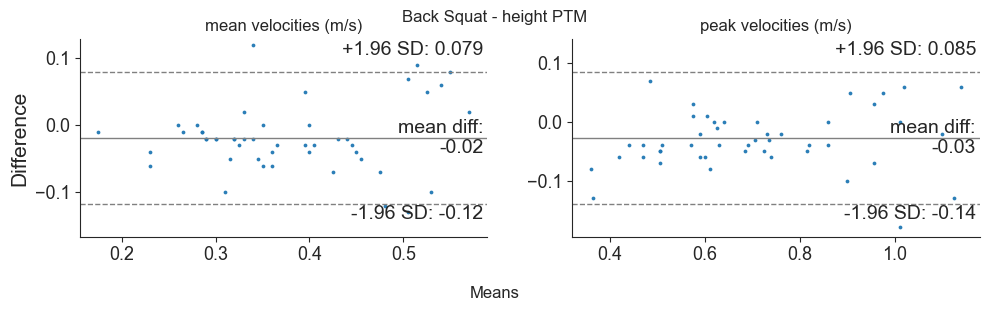

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Peak velocity,Back Squat,height,Optical motion capture,0.05,0.85,0.95
1,Mean velocity,Back Squat,height,Optical motion capture,0.04,0.83,0.86


In [1]:
import glob
from utilities import utils
from tasks import velocity

bsq = sorted(p for p in glob.glob("data/keypoints/bsq/*.txt") if "world" not in p.lower())
bsq_data = utils.read_list('bsq_data')

bsq_h = velocity.get_metrics(bsq, bsq_data, task='bsq', task_label='Back Squat', ptm='height')
bsq_h

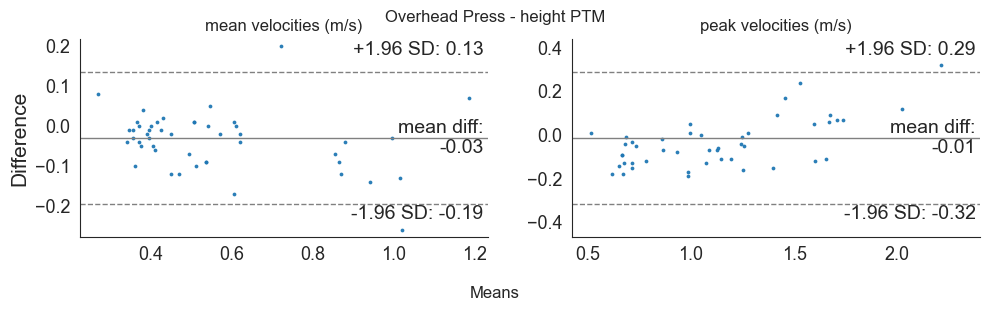

,Metric,Task,PTM Ref,Ground Truth,MAE,Reliability,ICC
0,Peak velocity,Overhead Press,height,Optical motion capture,0.11,0.89,0.94
1,Mean velocity,Overhead Press,height,Optical motion capture,0.06,0.80,0.92


In [2]:
ohp = sorted(p for p in glob.glob("data/keypoints/ohp/*.txt") if "world" not in p.lower())
ohp_data = utils.read_list('ohp_data')

ohp_h = velocity.get_metrics(ohp, ohp_data, task='ohp', task_label='Overhead Press', ptm='height')
ohp_h

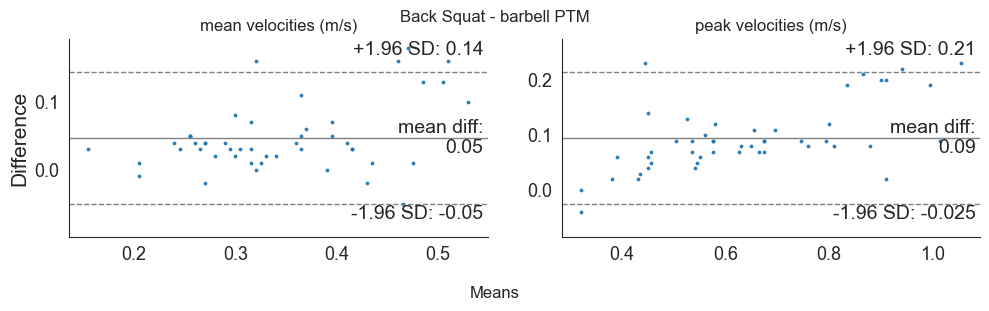

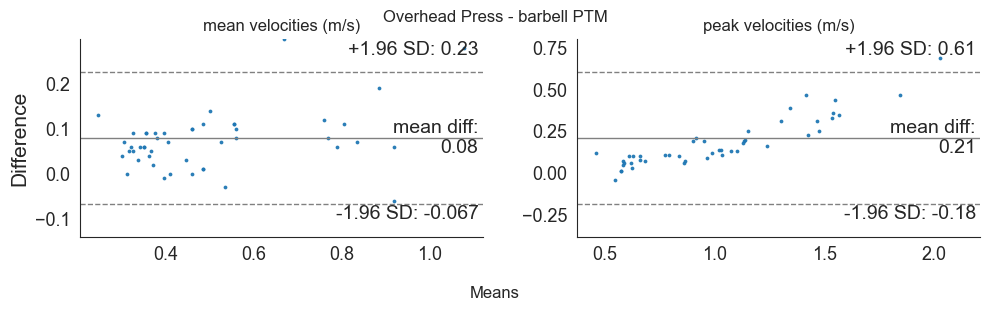

          Metric        Task  PTM Ref            Ground Truth   MAE  \
0  Peak velocity  Back Squat  barbell  Optical motion capture  0.10   
1  Mean velocity  Back Squat  barbell  Optical motion capture  0.05   

   Reliability   ICC  
0         0.85  0.85  
1         0.85  0.76  
          Metric            Task  PTM Ref            Ground Truth   MAE  \
0  Peak velocity  Overhead Press  barbell  Optical motion capture  0.21   
1  Mean velocity  Overhead Press  barbell  Optical motion capture  0.08   

   Reliability   ICC  
0         0.90  0.80  
1         0.82  0.87  


: 

In [ ]:
bsq_b = velocity.get_metrics(bsq, bsq_data, task='bsq', task_label='Back Squat', ptm='barbell')
ohp_b = velocity.get_metrics(ohp, ohp_data, task='ohp', task_label='Overhead Press', ptm='barbell')
print(bsq_b); print(ohp_b)